In [1]:
import os
import sys
PROJECT_ROOT = '/storage/scratch1/3/grubin6/2AFC'
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt


In [2]:
from notebook_tools.io import read_ops


In [3]:
list_session_data_path = [
    # 'F:\\Single_Interval_discrimination\\Data_2p\\YH24LG_CRBL_crux1_20250519_2afc-331',
    'F:\\Single_Interval_discrimination\\Data_2p\\YH24LG_CRBL_lobulev_20250709_2afc-545',
    # 'F:\\Single_Interval_discrimination\\Data_2p\\YH24LG_CRBL_simplex_20250528_2afc-373',
    # 'F:\\Single_Interval_discrimination\\Data_2p\\YH24LG_CRBL_simplex_20250529_2afc-379',
    # 'F:\\Single_Interval_discrimination\\Data_2p\\YH24LG_CRBL_simplex_20250530_2afc-389',
]

list_ops = read_ops(list_session_data_path)

In [4]:
from notebook_tools.io import create_memmap, get_memmap_path, read_masks


In [5]:
# label -1 --> excitattory neurons, 1 --> inhibitory neuons

[labels, masks, mean_func, max_func, mean_anat, masks_anat] = read_masks(list_ops[0])

# Raw volateges and dff

In [6]:
from notebook_tools.io import read_raw_voltages


In [7]:
[vol_time, vol_start, vol_stim_vis, vol_img,
            vol_hifi, vol_stim_aud, vol_flir,
            vol_pmt, vol_led] = read_raw_voltages(list_ops[0])

* Read dff

In [8]:
from notebook_tools.io import read_dff


In [9]:
dff = read_dff(list_ops[0])

* bpod

In [10]:
from notebook_tools.io import read_bpod_mat_data


In [11]:
from notebook_tools.io import remove_start_impulse, correct_vol_start, get_trigger_time, get_session_start_time, correct_time_img_center, save_trials


In [12]:
print('Reading dff traces and voltage recordings')
# dff = read_dff(list_ops[0])
# [vol_time, vol_start, vol_stim_vis, vol_img,
#     vol_hifi, vol_stim_aud, vol_flir,
#     vol_pmt, vol_led] = read_raw_voltages(list_ops[0])
vol_stim_vis = remove_start_impulse(vol_time, vol_stim_vis)
vol_stim_vis = correct_vol_start(vol_stim_vis)
session_start_time = get_session_start_time(vol_time, vol_start)
trial_labels = read_bpod_mat_data(list_ops[0], session_start_time)
print('Correcting 2p camera trigger time')
# signal trigger time stamps.
time_img, _   = get_trigger_time(vol_time, vol_img)
# correct imaging timing.
time_neuro = correct_time_img_center(time_img)
# save the final data.
print('Saving trial data')
save_trials(
    list_ops[0], time_neuro, dff, trial_labels,
    vol_time, vol_stim_vis,
    vol_stim_aud, vol_flir,
    vol_pmt, vol_led)


Reading dff traces and voltage recordings
Correcting 2p camera trigger time
Saving trial data


In [13]:
from notebook_tools.io import read_trial_label, zscore_normalize, read_neural_trials


In [14]:
neural_trials = read_neural_trials(list_ops[0], 1)
trial_labels = read_trial_label(list_ops[0])

1- finding block changs,2- segment for 10 trials around transition, 3- TCA

* Alignment for block transiton

* Aligning around transitions

i need to add outcomes isi, stim , etc

In [15]:
from notebook_tools.tca import process_transitions


In [16]:
cropped_len_stl

3134

Text(0.5, 1.0, 'Trial bounds (start/end indices) for one transition')

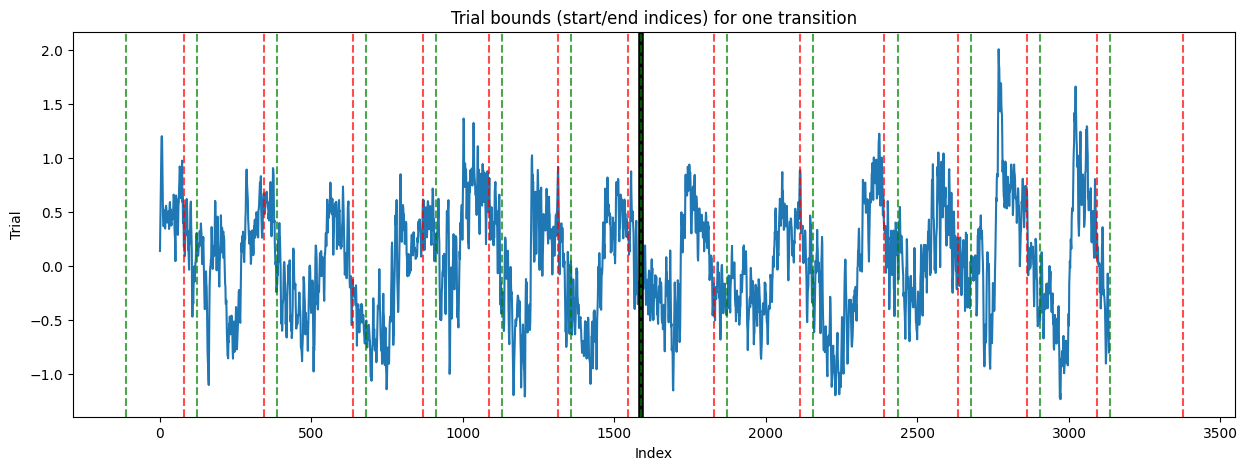

In [17]:
plt.figure(figsize=(15,5))
plt.plot(cropped_dff_stl[7,1,:])
plt.axvline(cropped_trans_indice_stl[0], linewidth = 4, color ='black')
# # Plot trial bounds as lines, each (x, y) pair is a trial segment
for (start_idx, end_idx) in cropped_bounds_stl[7]:
    plt.axvline(start_idx, color='g', linestyle='--', alpha=0.7)
    plt.axvline(end_idx, color='r', linestyle='--', alpha=0.7)
plt.xlabel('Index')
plt.ylabel('Trial')
plt.title('Trial bounds (start/end indices) for one transition')

# TCA

In [22]:
import tensortools as tt

data = cropped_dff_stl

# Fit an ensemble of models, 4 random replicates / optimization runs per model rank
ensemble = tt.Ensemble(fit_method="ncp_hals")
# The below is for fitting CP tensor decomposition
# ensemble = tt.Ensemble(nonneg=False, fit_method="cp_als")
ensemble.fit(data, ranks=range(1, 13), replicates=4)

Rank-1 models:  min obj, 1.00;  max obj, 1.00;  time to fit, 1.1s


Rank-2 models:  min obj, 0.99;  max obj, 0.99;  time to fit, 1.9s


Rank-3 models:  min obj, 0.99;  max obj, 0.99;  time to fit, 3.2s


Rank-4 models:  min obj, 0.98;  max obj, 0.99;  time to fit, 2.6s


Rank-5 models:  min obj, 0.98;  max obj, 0.98;  time to fit, 4.6s


...

Rank-8 models:  min obj, 0.97;  max obj, 0.97;  time to fit, 4.3s


Rank-9 models:  min obj, 0.97;  max obj, 0.97;  time to fit, 3.4s


Rank-10 models:  min obj, 0.97;  max obj, 0.97;  time to fit, 5.3s


Rank-11 models:  min obj, 0.97;  max obj, 0.97;  time to fit, 6.1s


Rank-12 models:  min obj, 0.96;  max obj, 0.97;  time to fit, 6.0s


In [25]:
nFactors = 12
# Tensot sahpe is factors, replicate = 0, (trial, neuron, time)
WeightPerTrial = ensemble.factors(nFactors)[0][0]
WeightPerNeurons = ensemble.factors(nFactors)[0][1]
WeightPerTime = ensemble.factors(nFactors)[0][2]

In [28]:
z = np.mean(cropped_bounds_stl, axis = 0)
z.shape

(14, 2)

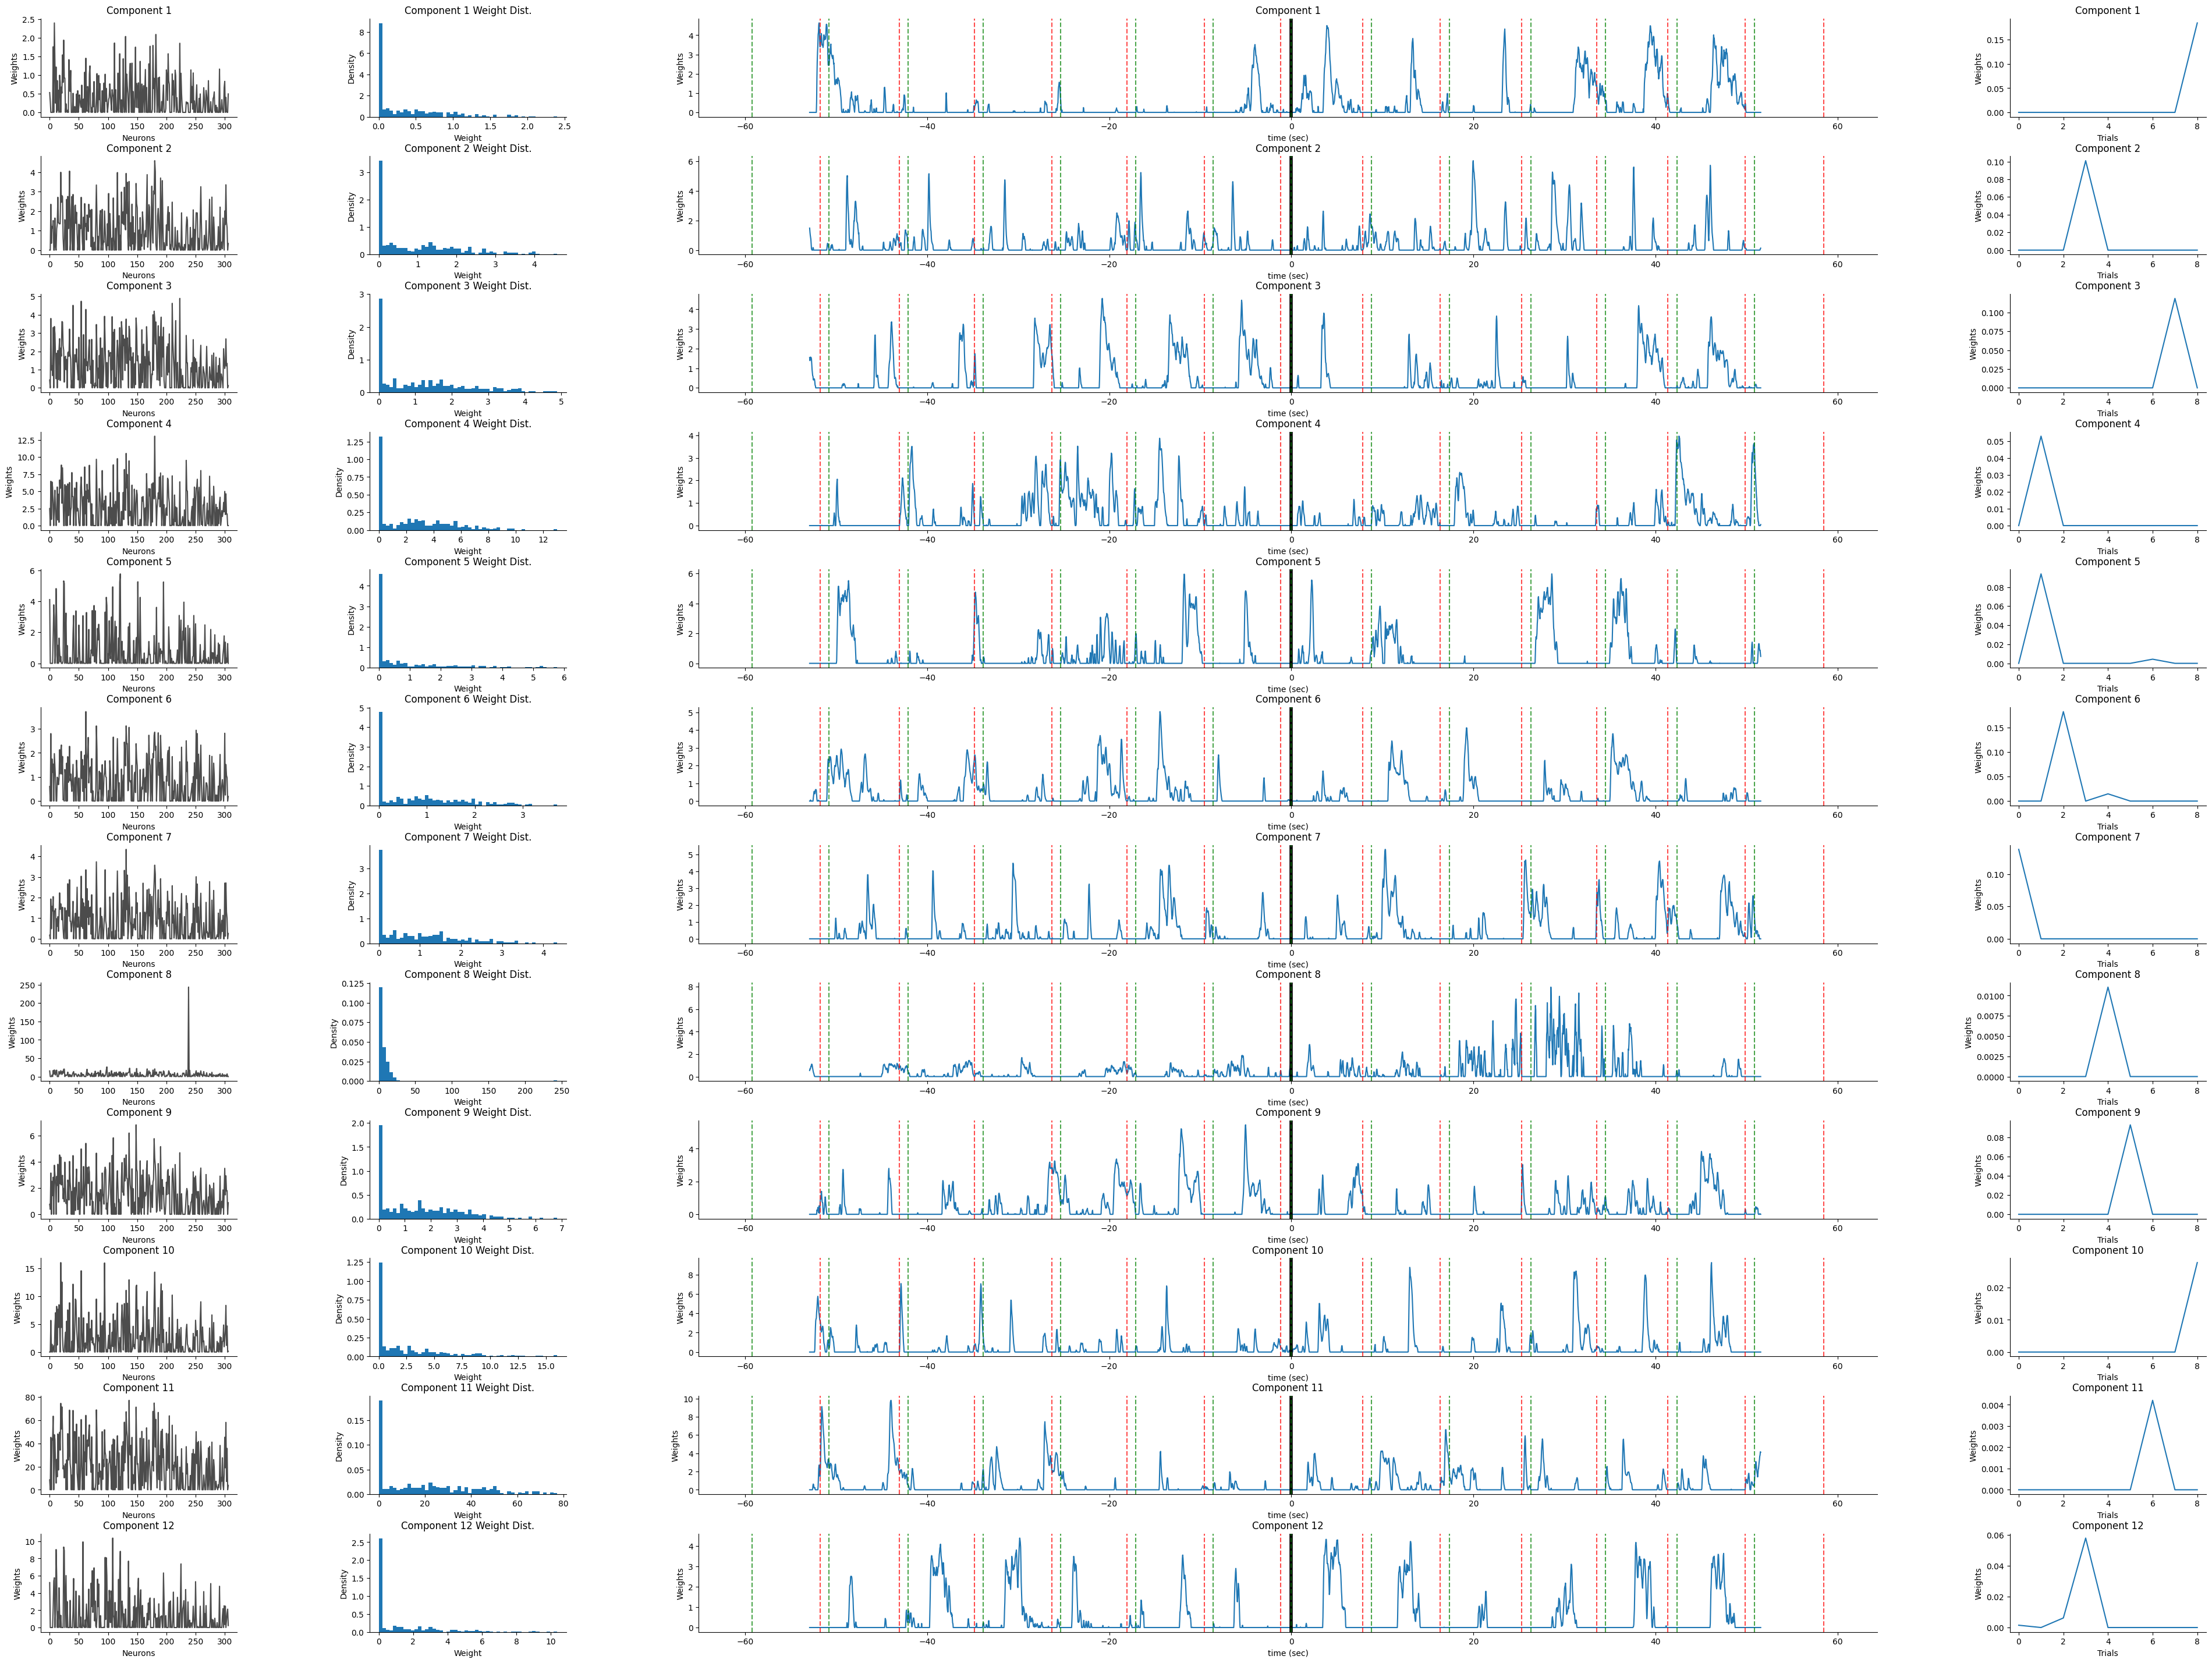

In [30]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Set up figure and GridSpec
fig = plt.figure(figsize=(48, 36))
width_ratios = [1, 1, 6, 1]  # Added extra column for distributions
height_ratios = [1] * nFactors  # Equal height for all rows
gs = gridspec.GridSpec(nFactors, 4, figure=fig, width_ratios=width_ratios, 
                       height_ratios=height_ratios, wspace=0.3, hspace=0.4)

time = (np.arange(cropped_len_stl) - cropped_trans_indice_stl[0])/30
for i in range(nFactors):

    # Plot 1: Weights per Trial
    ax1 = fig.add_subplot(gs[i, 3])
    ax1.plot(WeightPerTrial[:, i])
    ax1.set_title(f'Component {i + 1}')
    ax1.set_xlabel('Trials')
    ax1.set_ylabel('Weights')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    # ax1.legend()

    # Plot 2: Weights per Time
    ax2 = fig.add_subplot(gs[i, 2])
    ax2.plot(time, WeightPerTime[:, i])
    ax2.axvline(0, linewidth = 4, color ='black')
    # # Plot trial bounds as lines, each (x, y) pair is a trial segment
    for (start_idx, end_idx) in z - cropped_trans_indice_stl[0]:
        ax2.axvline(start_idx/30, color='g', linestyle='--', alpha=0.7)
        ax2.axvline(end_idx/30, color='r', linestyle='--', alpha=0.7)
    ax2.set_title(f'Component {i + 1}')
    ax2.set_xlabel('time (sec)')
    ax2.set_ylabel('Weights')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    # ax2.legend()

    # Plot 3: Weights per Neuron
    ax3 = fig.add_subplot(gs[i, 0])
    
    ax3.plot(WeightPerNeurons[:, i], color='black', alpha=0.7)
    
    ax3.set_title(f'Component {i + 1}')
    ax3.set_xlabel('Neurons')
    ax3.set_ylabel('Weights')
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)

    # Plot 4: Superimposed histogram of inh and exc neuron weights
    ax4 = fig.add_subplot(gs[i, 1])

    
    # Compute histogram bins to align both distributions
    all_weights = WeightPerNeurons[:,i]
    bins = np.histogram_bin_edges(all_weights, bins=50)
    ax4.hist(all_weights, bins = bins,  density=True)
    
    ax4.set_title(f'Component {i + 1} Weight Dist.')
    ax4.set_xlabel('Weight')
    ax4.set_ylabel('Density')
    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)

# Adjust layout
# fig.tight_layout()

# Save
plt.savefig('components_properties_short_to_long.pdf')
